In [1]:
from google.colab import files
uploaded = files.upload()

Saving diabetes_prediction_dataset.csv to diabetes_prediction_dataset.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier


In [3]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [4]:
DATA_PATH = "diabetes_prediction_dataset.csv"

In [5]:
df = pd.read_csv(DATA_PATH)

df.head(10)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
5,Female,20.0,0,0,never,27.32,6.6,85,0
6,Female,44.0,0,0,never,19.31,6.5,200,1
7,Female,79.0,0,0,No Info,23.86,5.7,85,0
8,Male,42.0,0,0,never,33.64,4.8,145,0
9,Female,32.0,0,0,never,27.32,5.0,100,0


In [6]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (100000, 9)

Missing values per column:


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
missing_count,0,0,0,0,0,0,0,0,0



Duplicate rows: 3854


In [8]:
target_col = "diabetes"
df[target_col].value_counts()

,count
diabetes,
0,91500
1,8500


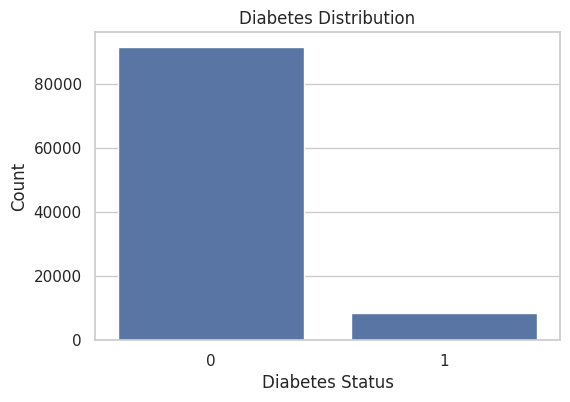

In [20]:
target_col = 'diabetes'
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Diabetes Distribution")
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.show()

In [11]:
df.dtypes

,0
gender,object
age,float64
hypertension,int64
heart_disease,int64
smoking_history,object
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


In [17]:
drop_cols = ["smoking_history"]


In [18]:
drop_cols = [c for c in drop_cols if c in df.columns]

In [19]:
df = df.drop(columns=drop_cols)

In [21]:
df_fe = df.copy()

df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 18, 45, 65, 100], labels=[0, 1, 2, 3])

df_fe['bmi_category'] = pd.cut(df_fe['bmi'], bins=[0, 18.5, 25, 30, 100], labels=[0, 1, 2, 3])

df_fe['high_risk_glucose'] = ((df_fe['HbA1c_level'] >= 6.5) | (df_fe['blood_glucose_level'] >= 200)).astype(int)

df_fe[['age', 'age_group', 'bmi', 'bmi_category', 'high_risk_glucose']].head(10)

,age,age_group,bmi,bmi_category,high_risk_glucose
0,80.0,3,25.19,2,1
1,54.0,2,27.32,2,1
2,28.0,1,27.32,2,0
3,36.0,1,23.45,1,0
4,76.0,3,20.14,1,0
5,20.0,1,27.32,2,1
6,44.0,1,19.31,1,1
7,79.0,3,23.86,1,0
8,42.0,1,33.64,3,0
9,32.0,1,27.32,2,0


In [22]:
df_fe["glucose_hba1c_ratio"] = df_fe["blood_glucose_level"] / df_fe["HbA1c_level"]

df_fe[["blood_glucose_level", "HbA1c_level", "glucose_hba1c_ratio"]].head(10)

,blood_glucose_level,HbA1c_level,glucose_hba1c_ratio
0,140,6.6,21.212121
1,80,6.6,12.121212
2,158,5.7,27.719298
3,155,5.0,31.000000
4,155,4.8,32.291667
5,85,6.6,12.878788
6,200,6.5,30.769231
7,85,5.7,14.912281
8,145,4.8,30.208333
9,100,5.0,20.000000


In [23]:
def calculate_risk_score(age, bmi, glucose):
    return (age * 0.1) + (bmi * 0.3) + (glucose * 0.6)

risk_features = {"age", "bmi", "blood_glucose_level"}
if risk_features.issubset(set(df_fe.columns)):
    df_fe["health_risk_score"] = calculate_risk_score(
        df_fe["age"],
        df_fe["bmi"],
        df_fe["blood_glucose_level"]
    )
    print(df_fe[["age", "bmi", "blood_glucose_level", "health_risk_score"]].head(10))
else:
    print("Required columns not found. Skipping risk score calculation.")

    age    bmi  blood_glucose_level  health_risk_score
0  80.0  25.19                  140             99.557
1  54.0  27.32                   80             61.596
2  28.0  27.32                  158            105.796
3  36.0  23.45                  155            103.635
4  76.0  20.14                  155            106.642
5  20.0  27.32                   85             61.196
6  44.0  19.31                  200            130.193
7  79.0  23.86                   85             66.058
8  42.0  33.64                  145            101.292
9  32.0  27.32                  100             71.396


In [27]:
categorical_cols = ['gender', 'smoking_history']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])



Accuracy: 0.9695
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18292
           1       0.93      0.69      0.80      1708

    accuracy                           0.97     20000
   macro avg       0.95      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



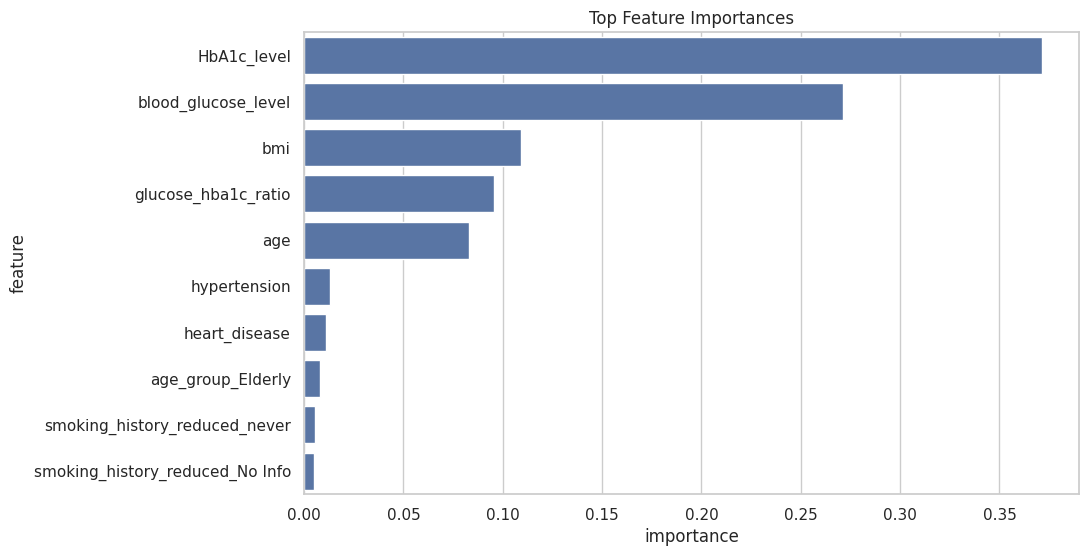

In [34]:

top_k = 3
top_categories = df_fe['smoking_history'].value_counts().nlargest(top_k).index
df_fe['smoking_history_reduced'] = df_fe['smoking_history'].where(df_fe['smoking_history'].isin(top_categories), 'Other')

df_fe["glucose_hba1c_ratio"] = df_fe["blood_glucose_level"] / df_fe["HbA1c_level"]
df_fe['age_group'] = pd.cut(df_fe['age'], bins=[0, 18, 45, 65, 100], labels=['Child', 'Adult', 'Senior', 'Elderly'])

categorical_cols = ['gender', 'smoking_history_reduced', 'age_group']
numeric_cols = ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'glucose_hba1c_ratio']

X = df_fe[categorical_cols + numeric_cols]
y = df_fe['diabetes']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols)
    ])

model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols)
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_
fi = pd.DataFrame({"feature": all_feature_names, "importance": importances}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=fi.head(10), x="importance", y="feature")
plt.title("Top Feature Importances")
plt.show()